# Introduction

## Data Background

Cryo-transmission electron microscopy (cryo-TEM) can be used to capture in tomographic schemes, and doing so is called cryo-electron tomography (cryo-ET). Cryo-ET data used in this project has been taken from the following deposited data in EMPIAR 10988:
https://www.ebi.ac.uk/empiar/EMPIAR-10988/

This data is related to the paper: de Teresa-Trueba, I., Goetz, S.K., Mattausch, A. et al. Convolutional networks for supervised mining of molecular patterns within cellular context. Nat Methods 20, 284–294 (2023). https://doi.org/10.1038/s41592-022-01746-2 which can be found in the folder of this project.

The authors have uploaded a total of 10 datasets to the public EMPIAR database, and this project uses the first of the ten. The data has been uploaded in various stages of cryo-ET processing by the publishing authors, such as final tomograms and their respective tilt series. Tilt series is a collection of cryo-EM images of the same place in a sample, but the sample is tilted and imaged multiple times so that many angles are captured. This series of images undergo preprocessing and then are used to reconstruct a 3D volume of the entire "slice" of sample imaged in the tilt series. Alongside these images and volumes, the authors have uploaded the coordinates of the ribosomes found in the 3D tomogram, which are the coordinates used in the project below.

## Project Motivation

Cryo-ET is able to image everything in a cell in unprecidented detail! However, only large structures and large macromolecular complexes, such as ribosomes (sizes around 10-20 nm), can be easily identified within the images. This is because heterogeneity of the biological matter in a dataset has to be sifted and sorted through in order to resolve each component. Without going into too much detail, there are few barriers must be overcome to achieve high resolution of biomacromolecular structures in cryo-TEM imaging. These barriers are only overcome by capturing many images of the same molecule and overlaying them in order to improve the signal to noise ratio (SNR) such that enough signal can characterize a biological particle to high resolution. If you cannot sort through the heterogeneous population of biomolecules, you will not be able to improve SNR. This becomes a particularly difficult issue when biomolecules are smaller in size, as the per-particle signal is lower and they are more difficult to differentiate from one another than the larger particles.

I want to look at spatial distributions of particles in tomograms for two reasons:

1. Spatial disribution and the patterns of biomolecule distribution may be a useful prior to help sort out biological heterogeneity within a cryo-TEM dataset
2. Spatial patterns found in a cryo-TEM datasets might be able to be corroborated by other microscopies, such as whole-cell flourescence, small angle scattering, or even crosslinking methods. 

Priors are extremely influential in cryo-EM processing, so in this notebook I hope to extract information about the spatial distribution and possibly patterns of the particles in the data in order to provide insight that could be used as priors during processing downstream in the cryo-TEM analysis pipeline. 

Specifically, we want to look at distances between ribosomes in order to determine subpopulations that might be interacting with eachother or interacting with similar co-binders. Spacing of ribosomes has been tied to function - for example when ribosomes are tightly packed on a mRNA strand they are more likely to all slip in a programmed frameshifting mechanism. Additionally, it's fairly well characterized that macromolecules function according to hyper-local environment, anything in direct proximity is much more likely to bind and influence the function of it's neighbor. As everything is fairly tightly packed in a cell, the spacing from one complex to the next is unlikely due to pure chance, and spatial patters or distributions might be helpful in understanding the neighboring components and functional sub-populations - two insights that can be extremely helpful in deconvolution of macromolecular heterogeneity during cryo-TEM analysis.

In [1]:
#importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

In this project we work with coordinates of ribosomes taken from a tomogram. First we will want to import all the assigned ribosomes from the data entry. Particle_lists.txt (can be found uploaded in EMPIAR_10988_Particle_Locations) states these files contain x, y, z coordinates. Voxels are 4xbined with the original pixel size 3.37 Angstroms. Thus 1 coordinate pixel = 4 * 3.3702 Å = 13.4808 Å, however since we are looking at patterns and X, Y,and Z are in the same lengthscale, we will work with the data as deposited by the authors, as they might have their reasons behind deposition of coordinates. For example, the authors might have a better idea of possible morphing of the 3D space during image processing and tomogram reconstruction.

In [2]:
#importing the ribosome coordinates from a single tomogram
file_path = 'TS_026_cyto_ribosomes.csv'
df_026_rib = pd.read_csv(file_path, header=None)

#assigning each column with correct coordinate, checking data
df_026_rib.columns = ['x','y','z']
df_026_rib.head(10)

,x,y,z
0,517,261,469
1,881,689,530
2,949,703,531
3,940,723,532
4,459,688,530
5,438,697,531
6,447,647,531
7,360,711,531
8,343,754,531
9,354,780,530


There are 838 ribosomes identified in the tomogram, which is named tomogram #26 by the authors of this research paper. Information of each single ribosome is captured in a row and the columns of the dataframe contains the X,Y,X coordinates of the ribosomes captured in 3D space in the tomogram.

With these coordinates, I'd like to focus on how the ribosomes may be spaced in relation to one another and try to pull out spatial patterns, as these patterns might indicate ribosomes are doing similar translational roles.

# Analysis:
### First look at the ribosomes in tomogram #26


In [3]:
#conversion to numpy array for plotting, ect.
coords_026 = df_026_rib[['x','y','z']].to_numpy()
coords_026

array([[517, 261, 469],
       [881, 689, 530],
       [949, 703, 531],
       ...,
       [418, 848, 539],
       [839, 813, 546],
       [538, 723, 519]], shape=(838, 3))

Below are all the ribosomal positions visualized

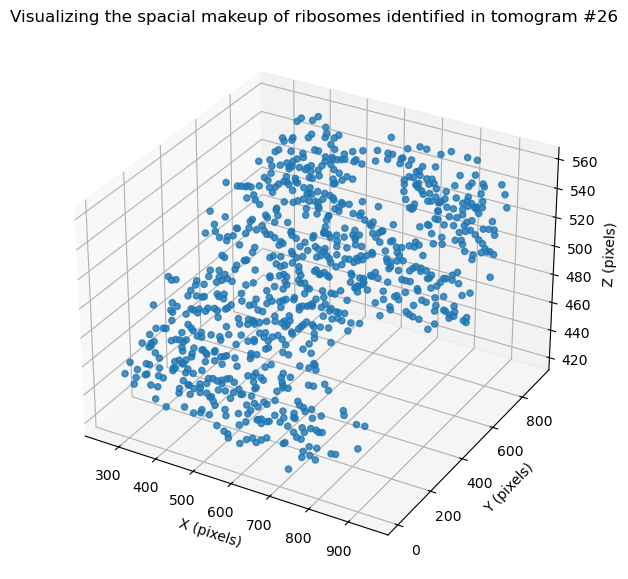

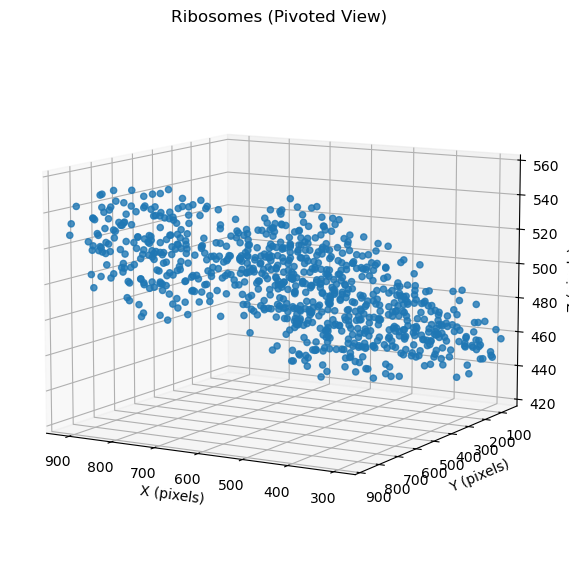

In [4]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2], s=20, alpha=0.8)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('Visualizing the spacial makeup of ribosomes identified in tomogram #26')
plt.show()

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2], s=20, alpha=0.8)
ax.view_init(elev=10, azim=120)

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('Ribosomes (Pivoted View)')

#adjusting the limits slightly to ensure the plot is centered
ax.set_xlim(coords_026[:, 0].min() - 5, coords_026[:, 0].max() + 5)
ax.set_ylim(coords_026[:, 1].min() - 5, coords_026[:, 1].max() + 5)
ax.set_zlim(coords_026[:, 2].min() - 5, coords_026[:, 2].max() + 5)

plt.show()

Already, we can see ribosomes that appear to be lined up or bunched together in certain areas! Some simple examples of what we might be seeing when is multiple ribosomes bound to a single mRNA and/or possibly ribosomes that are lined up on the endoplasmic reticulum (ER) that are all syntheizing new membrane-bound proteins directly into the ER membrane. 

In the paper for this data, they were able to reconstruct a ribosome from the picked particles, confirming each particle is indeed a ribosome. Thus, I'm not looking to try to use ER density or any other biological that might be labeled by the authors in my analysis, as I'd like my analysis to be based solely on ribosomal locations and possible spatial patterns found within these locations. I hope it's possible to pull out patterns in ribosome spatial relationships without input from any other information, as assignment any other macromolecular particles can have inherent error and are more difficult to validate than these ribosomes.

### Kmeans clustering of ribosomal positions in tomogram #26
Kmeans clustering could be worthwhile to look at as a starting point. The output of clustering is not a great indicator of patters of 3D positioning of the ribosomes in 3D space, it could be a good first look at the data and might help us understand subpopulations of ribosomes. We won't take too long figuring out the "best" value of k for this, as this is more exploratory analysis and visualization. 

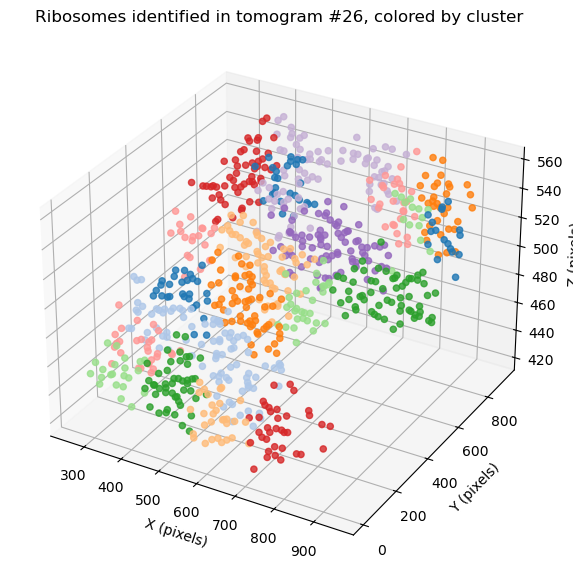

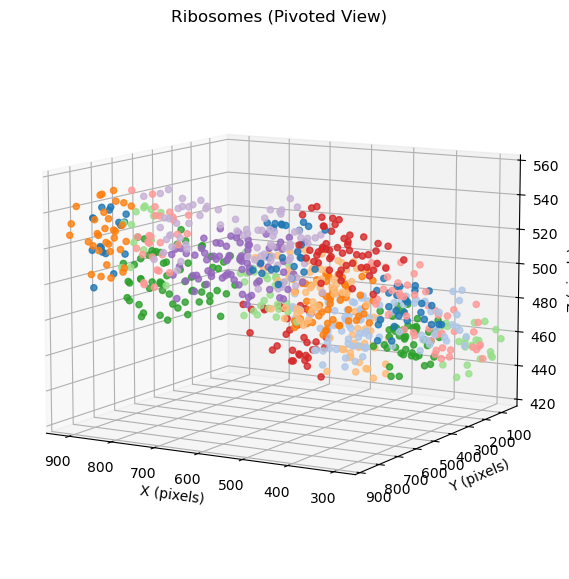

In [5]:
kmeans = KMeans(n_clusters=30, random_state=0)
kmeans.fit(coords_026)
# pull for plotting
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
kmeans_colors = plt.cm.tab20(labels.astype(int) % 10)
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2], s=20, alpha=0.8, c=kmeans_colors)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('Ribosomes identified in tomogram #26, colored by cluster')
plt.show()
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2], s=20, alpha=0.8, c=kmeans_colors)
ax.view_init(elev=10, azim=120)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('Ribosomes (Pivoted View)')
ax.set_xlim(coords_026[:, 0].min() - 5, coords_026[:, 0].max() + 5)
ax.set_ylim(coords_026[:, 1].min() - 5, coords_026[:, 1].max() + 5)
ax.set_zlim(coords_026[:, 2].min() - 5, coords_026[:, 2].max() + 5)
plt.show()

#### Kmeans Result
As we both probably guessed, clustering seems to be mostly based on the shape of the data points, and not the patterns of the datapoints. 

### DBSCAN analysis of ribosomal positions in tomogram #26
Density Based Spatial Clustering of Applications with Noise (DBSCAN) might be a more suitable analytical technique to identify spatial patterns in the ribosomes in this tomogram. DBSCAN can define clusters of more arbitray shapes than kmeans because it uses multiple core points to start defining a cluster of core instead of a centroids. The minimum number of core points needed to define a cluster is defined as epsilon, and can be predicted using a KNN elbow plot. This plot distances between points, with the left most curve/elbow showing the distances at which the particles start to become more sparsely distributed.

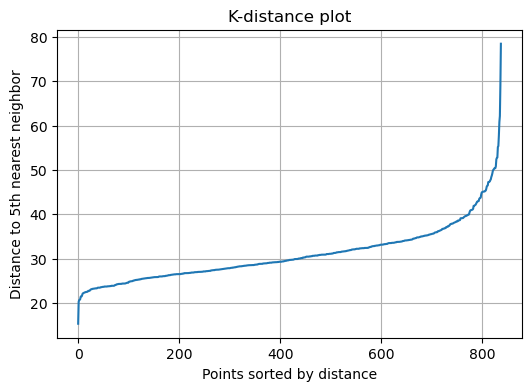

elbow esp value is
43.657759905886145


In [6]:
k = 5  # 5 is standard for DBSCAN parameter tuning
nbrs = NearestNeighbors(n_neighbors=k).fit(coords_026)
distances, indices = nbrs.kneighbors(coords_026)
k_distances = np.sort(distances[:, -1])
#plotting K-distance curve (finding “elbow” for eps)
plt.figure(figsize=(6,4))
plt.plot(k_distances)
plt.ylabel(f"Distance to {k}th nearest neighbor")
plt.xlabel("Points sorted by distance")
plt.title("K-distance plot")
plt.grid(True)
plt.show()
eps_value = k_distances[int(len(k_distances) * 0.95)]  # example: ~95th percentile
print('elbow esp value is')
print(eps_value)

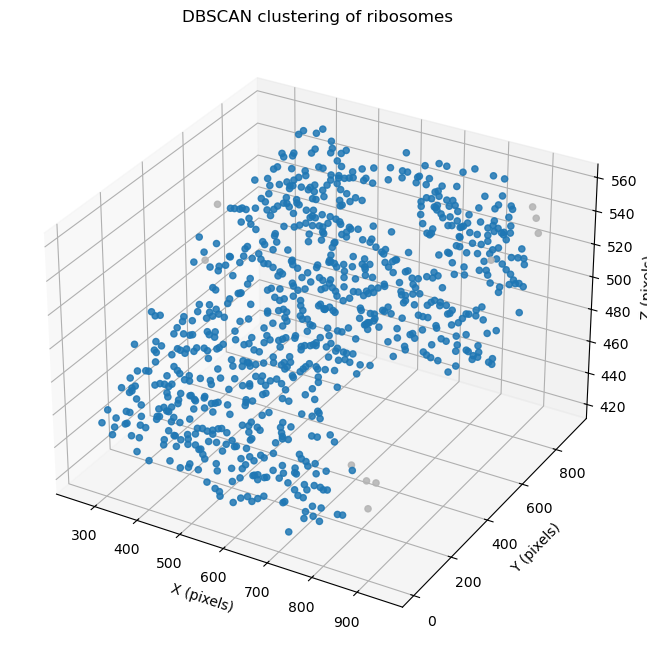

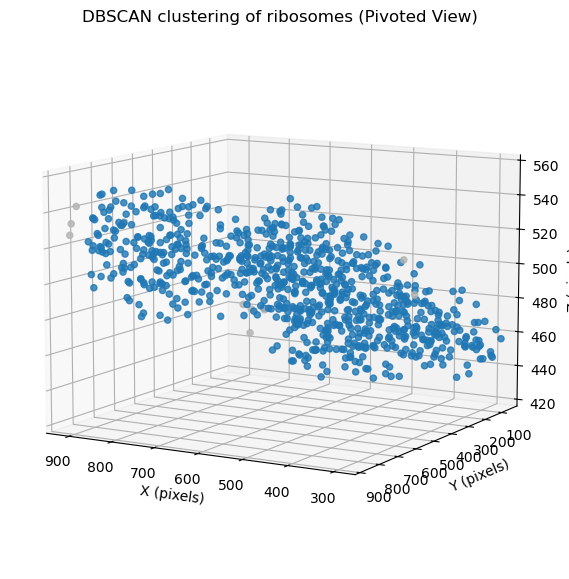

In [7]:
dbscan = DBSCAN(eps=eps_value, min_samples=k).fit(coords_026)
labels = dbscan.labels_
df_026_rib['cluster'] = labels

#for 3D plot of DBSCAN clusters
unique_labels = np.unique(labels)
dbscancolors = plt.cm.tab20((labels.astype(int) % 20))

#colors noise (label = -1) as grey
dbscancolors[labels == -1] = [0.7, 0.7, 0.7,1]
fig = plt.figure(figsize=(9,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2],
           s=20, c=dbscancolors, alpha=0.85)

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('DBSCAN clustering of ribosomes')
plt.show()
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2], s=20, alpha=0.8, c=dbscancolors)
ax.view_init(elev=10, azim=120)

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('DBSCAN clustering of ribosomes (Pivoted View)')
ax.set_xlim(coords_026[:, 0].min() - 5, coords_026[:, 0].max() + 5)
ax.set_ylim(coords_026[:, 1].min() - 5, coords_026[:, 1].max() + 5)
ax.set_zlim(coords_026[:, 2].min() - 5, coords_026[:, 2].max() + 5)
plt.show()

It looks like there are no clusters picked up in this analysis, the grey points are just identified as noise and are labeled as such. In the hopes to try to increase the sensativity, I decrease the value of min_samples. This is not often recommended as it essentially is more likely to appraise fluctuations in noise to be considered real and treated as a cluster core.

elbow esp value is
38.65229618017538


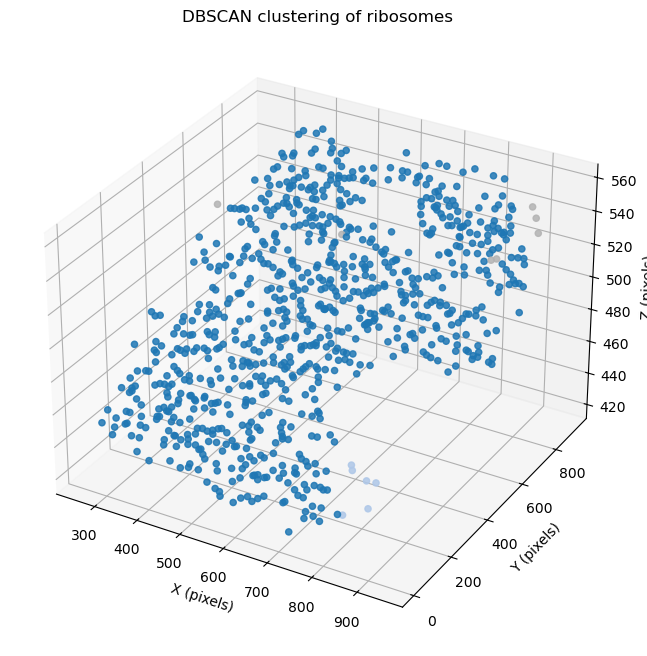

In [8]:
k = 4 # dropping value to only needing 3 neighbors to form a real cluster
nbrs = NearestNeighbors(n_neighbors=k).fit(coords_026)
distances, indices = nbrs.kneighbors(coords_026)
k_distances = np.sort(distances[:, -1])
eps_value = k_distances[int(len(k_distances) * 0.95)]  # example: ~95th percentile
print('elbow esp value is')
print(eps_value)

dbscan = DBSCAN(eps=eps_value, min_samples=k).fit(coords_026)
labels = dbscan.labels_
df_026_rib['cluster'] = labels

#for 3D plot of DBSCAN clusters
unique_labels = np.unique(labels)
dbscancolors = plt.cm.tab20((labels.astype(int) % 20))

# color noise (label = -1) as grey
dbscancolors[labels == -1] = [0.7, 0.7, 0.7,1]
fig = plt.figure(figsize=(9,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2],
           s=20, c=dbscancolors, alpha=0.85)

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Z (pixels)')
ax.set_title('DBSCAN clustering of ribosomes')
plt.show()

#### DBSCAN Result
Dropping the min_value to 4 shows points once noted as noise are now considered clusters. This shows that any changes in spatial density of ribosomes within the tomogram may not great enough to be discovered using DBSCAN.

Heirarchical DBSCAN (HDBSCAN) may be a reasonable option to try next for finding patterns in the spatial distributions of ribosomes. This drops reliance on the epsilon parameter and builds a heirarchy across all distances ranges, meaning it can find clusters of different densities simultaneously. As I have personally tried quite a few epsilons on this dataset outside of what is reported above, I don't have much confidence that this would produce robust clustering. Additionally, HDBSCAN is computationally heavy and this project has run-time limitations.

### Agglomerative Clustering of ribosomal positions in tomogram #26
Finally, I'll attempt the bottom-up approach of agglomerative clustering. Think of this as if it's building clusters from the bottom up, starting with one and then adding onto that - like a tree and we get to decide at which merge to stop at in order to check out the potential patterns captured. For linkage type, I've used "average" parameter as this defines clusters by the distance between clusters as the averages distance between all the pairs of points. I hope this allows clustering to happen without being confined to a certain shape, and also allows clustering to be less affected by outliers.

In [9]:
#agg model
agg_clustering = AgglomerativeClustering(
    n_clusters=None,           #let distances decide cluster number
    distance_threshold=135,  
    linkage='average'           
)
#get cluster labels
labels = agg_clustering.fit_predict(coords_026)

#add to dataframe
df_026_rib['hierarchical_cluster'] = labels

# Let's see what we found
n_clusters = len(set(labels))
print(f"number of clusters found: {n_clusters}")
print(f"\nCluster size distribution:")

for cluster_id in sorted(set(labels)):
    cluster_size = list(labels).count(cluster_id)
    print(f"  Cluster {cluster_id}: {cluster_size} ribosomes")

number of clusters found: 21

Cluster size distribution:
  Cluster 0: 44 ribosomes
  Cluster 1: 62 ribosomes
  Cluster 2: 42 ribosomes
  Cluster 3: 20 ribosomes
  Cluster 4: 66 ribosomes
  Cluster 5: 70 ribosomes
  Cluster 6: 54 ribosomes
  Cluster 7: 40 ribosomes
  Cluster 8: 34 ribosomes
  Cluster 9: 45 ribosomes
  Cluster 10: 36 ribosomes
  Cluster 11: 56 ribosomes
  Cluster 12: 33 ribosomes
  Cluster 13: 26 ribosomes
  Cluster 14: 25 ribosomes
  Cluster 15: 48 ribosomes
  Cluster 16: 16 ribosomes
  Cluster 17: 28 ribosomes
  Cluster 18: 37 ribosomes
  Cluster 19: 38 ribosomes
  Cluster 20: 18 ribosomes


Dendrogram of this model:

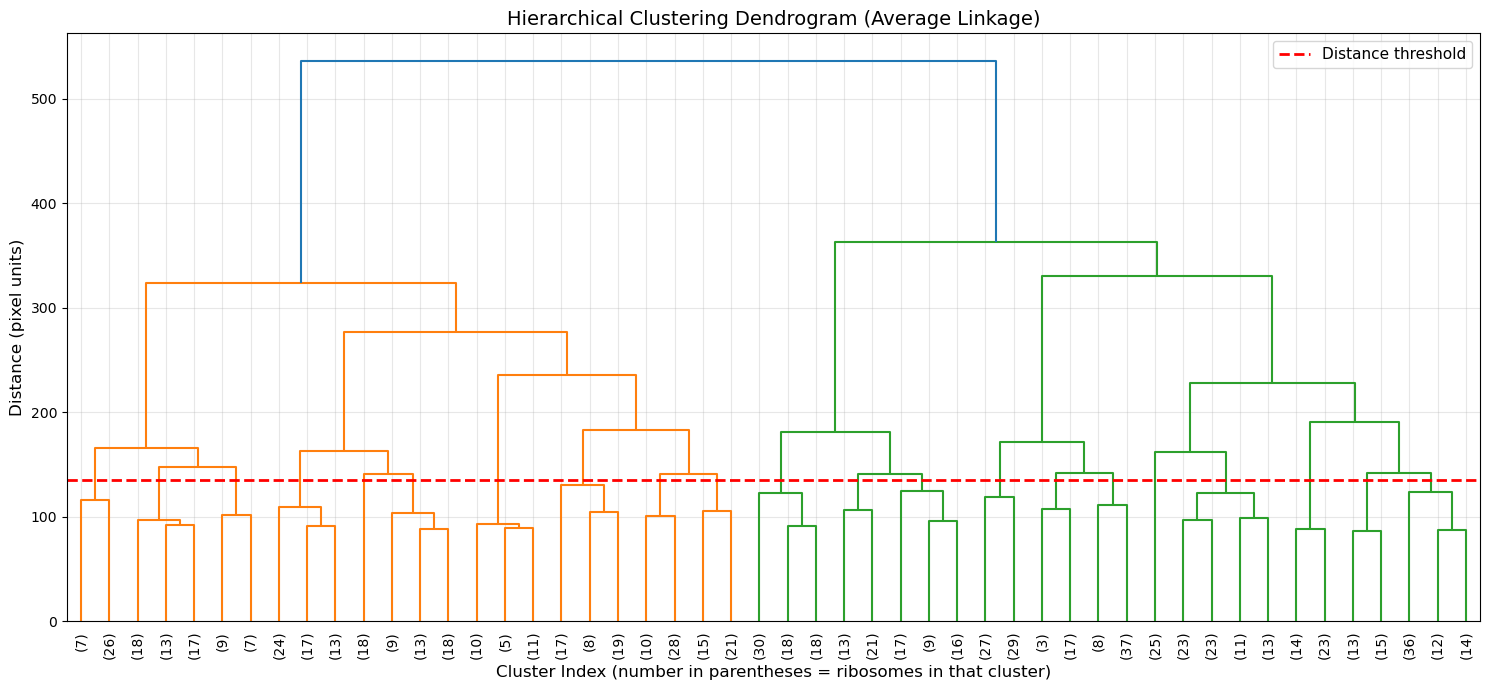

In [10]:
linkage_matrix = linkage(coords_026, method='average')

#dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, 
           truncate_mode='lastp',      
           p=50,                       
           show_leaf_counts=True,      
           leaf_font_size=10)

plt.title('Hierarchical Clustering Dendrogram (Average Linkage)', 
          fontsize=14)
plt.xlabel('Cluster Index (number in parentheses = ribosomes in that cluster)', fontsize=12)
plt.ylabel('Distance (pixel units)', fontsize=12)


y_thresh = 135
plt.axhline(y=y_thresh, color='r', linestyle='--', linewidth=2, label='Distance threshold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Clustering results plotted on ribosomal locations

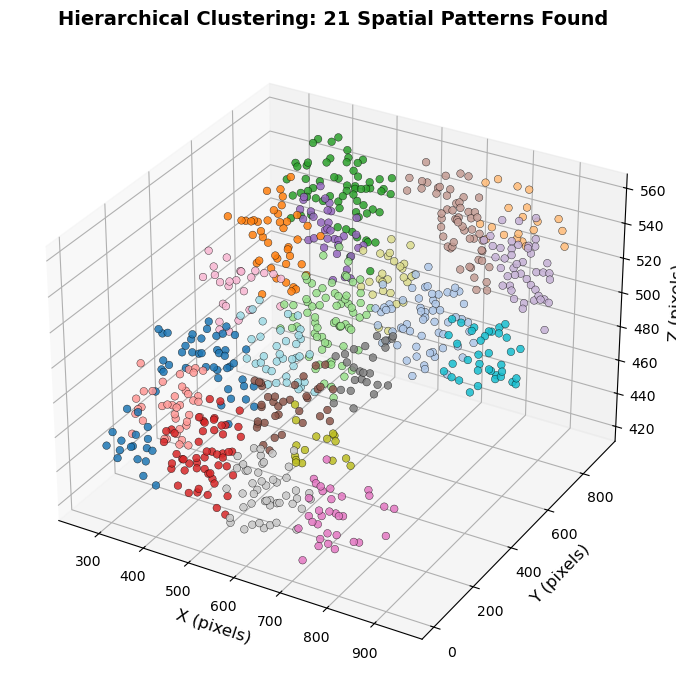

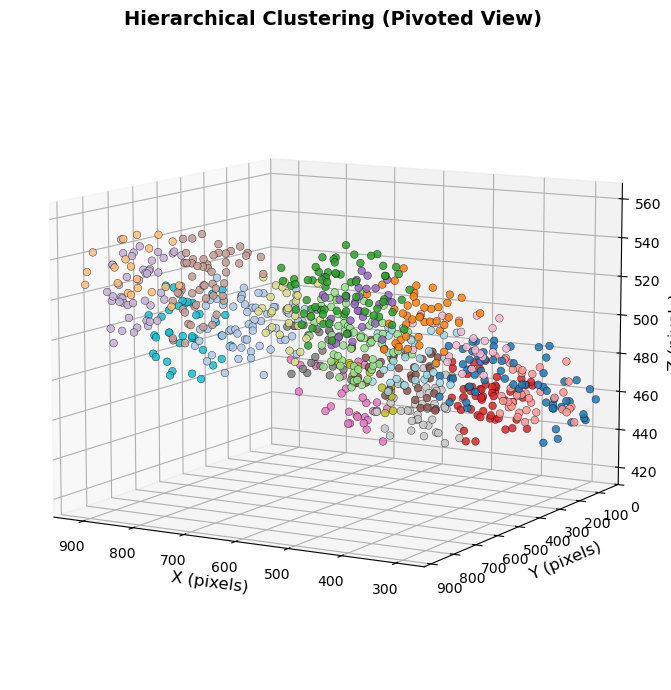

In [11]:
#making it a bit prettier
unique_labels = np.unique(labels)
hier_colors = plt.cm.tab20((labels.astype(int) % 20))
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2],
                     s=30, c=hier_colors, alpha=0.85, edgecolors='black', linewidth=0.3)
ax.set_xlabel('X (pixels)', fontsize=12)
ax.set_ylabel('Y (pixels)', fontsize=12)
ax.set_zlabel('Z (pixels)', fontsize=12)
ax.set_title(f'Hierarchical Clustering: {n_clusters} Spatial Patterns Found', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Pivoted view
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords_026[:,0], coords_026[:,1], coords_026[:,2], 
           s=30, c=hier_colors, alpha=0.85, edgecolors='black', linewidth=0.3)
ax.view_init(elev=10, azim=120)
ax.set_xlabel('X (pixels)', fontsize=12)
ax.set_ylabel('Y (pixels)', fontsize=12)
ax.set_zlabel('Z (pixels)', fontsize=12)
ax.set_title('Hierarchical Clustering (Pivoted View)', fontsize=14, fontweight='bold')
ax.set_xlim(coords_026[:, 0].min() - 10, coords_026[:, 0].max() + 10)
ax.set_ylim(coords_026[:, 1].min() - 10, coords_026[:, 1].max() + 10)
ax.set_zlim(coords_026[:, 2].min() - 10, coords_026[:, 2].max() + 10)
plt.tight_layout()
plt.show()

#### Agglomerative Clustering Result
There does appear to be a possible detection of a single cluster of 16 ribosomes in the top corner where Z is around 540 and X and Y are about 800-900. The group does appear to be more spaced out that the other clusters! For more fine-tuned analysis, let's look at the spatial spread within the clusters. The coefficient of variation (CV) is a measure of variability and is found by dividing the standard deviation by the mean. A low CV would indicate consistent spacing, with a general consistency threshold is thought to be around 0.35 for consistently spaced particles in a regular pattern.

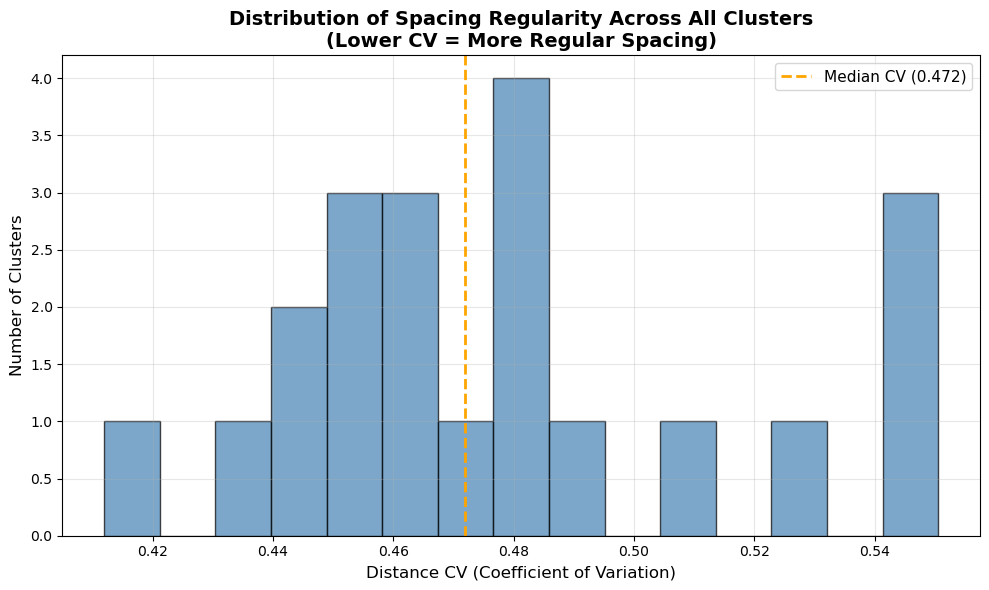

In [12]:
cluster_data = []

for cluster_id in sorted(set(labels)):
    cluster_mask = labels == cluster_id
    cluster_points = coords_026[cluster_mask]
    cluster_size = len(cluster_points)
    
    if cluster_size < 3:
        continue
    
    #calculate pairwise distances
    cluster_distances = pdist(cluster_points, metric='euclidean')
    distance_cv = cluster_distances.std() / cluster_distances.mean()
    
    cluster_data.append({
        'Cluster': cluster_id,
        'Size': cluster_size,
        'Distance_CV': distance_cv
    })

df_all_clusters = pd.DataFrame(cluster_data)

plt.figure(figsize=(10, 6))
plt.hist(df_all_clusters['Distance_CV'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=df_all_clusters['Distance_CV'].median(), color='orange', linestyle='--', 
            linewidth=2, label=f'Median CV ({df_all_clusters["Distance_CV"].median():.3f})')
plt.xlabel('Distance CV (Coefficient of Variation)', fontsize=12)
plt.ylabel('Number of Clusters', fontsize=12)
plt.title('Distribution of Spacing Regularity Across All Clusters\n(Lower CV = More Regular Spacing)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

While maybe one or two clusters have lower spacing variability, it doesn't appear that we have been able to capture robust spacial patterns in these ribosomes.

## Discussion

No doubt, throughout this notebook you were likely shouting at me "use neural networks for this!" And you're correct, neural networks are currently the most promising option in the field when trying to parse through heterogeneity of the biological molecules captured in images. The issue with neural networks is that they are used heavily for particle picking and using them for picking the particles and then using them again for extracting patterns from the particles may double down on phantom signals in the data. Neural networks still are not very good at sorting through the biological heterogeneity in a sample and often getting very "distracted" by imaging artifacts. Thus, they require a heavy hand during training to get around neural networks focusing on the imaging artifacts. I was really hoping to be able to pull something out with just spatial patterns, as it would have less user curation and possibly less introduced bias.

It is possible this could work on different biomolecules, like large integral membrane proteins. For example, I could try to look at the Ryanodine Receptor (RyR) on the Sarcoplasmic Reticulum (SR). It is thought that RyRs might clump together in 2D crystal-like matrices on the membrane, which would allow a chain reaction to occur such that when one RyR opens up it prompts all the RyRs in the matrix to open - releasing the flood of calcium that allows your muscle to contract. If only I could find this data, but no one has imaged native RyRs on the SR yet with cryo-ET.

It might work well to employ Gaussian Mixture Models for clustering, as we should be able to incorporate priors because bayes theorem is used during both Eexpectation (E) and Maximization (M) steps of GMM's EM iterations.